In [1]:
import pandas as pd 
import numpy as np 
import sys 
import gffutils 
from typing import List, Set
import seaborn as sns 
import matplotlib.pyplot as plt

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

def extract_unique_transcripts(juncs: pd.DataFrame) -> List[str]:
    """
    Extract unique transcripts from all transcript-related columns in junction DataFrame.
    Handles string lists, NA values, and ensures uniqueness.
    
    Args:
        juncs: DataFrame containing junction data with transcript columns
        
    Returns:
        List of unique transcript IDs
    """
    # Columns to extract transcripts from
    transcript_columns = [
        "perfect_match_5_prime", 
        "perfect_match_3_prime"
    ]
    
    # Set to store unique transcripts
    all_transcripts: Set[str] = set()
    
    # Process each column
    for column in transcript_columns:
        if column not in juncs.columns:
            print(f"Warning: Column '{column}' not found in DataFrame")
            continue
            
        # Process each row in the column
        for value in juncs[column]:
            # Skip NA/None values
            if pd.isna(value) or value == 'NA' or value is None:
                continue
                
            # Handle string lists (comma-separated values)
            if isinstance(value, str):
                # Skip empty strings
                if value.strip() == '':
                    continue
                    
                # Split by comma and add each transcript to the set
                for transcript in value.split(','):
                    transcript = transcript.strip()
                    if transcript and transcript != 'NA':
                        all_transcripts.add(transcript)
            
            # Handle actual Python lists
            elif isinstance(value, list):
                for transcript in value:
                    if transcript and not pd.isna(transcript) and transcript != 'NA':
                        all_transcripts.add(str(transcript))
    
    # Convert set to sorted list for consistent output
    return sorted(list(all_transcripts))

def process_and_visualize_atse_event(atse_event, human_atse, db_human, padding=5000, 
                                    base_width=10, trans_height=1, show_usage=False, 
                                    show_junc_lines=False, filename=None):
    """
    Process and visualize a single ATSE event.
    
    Args:
        atse_event (str): The ID of the ATSE event to process (e.g., "ATSE_6263")
        human_atse (pd.DataFrame): DataFrame containing ATSE data
        db_human (GenomeDB): Database object for genomic annotations
        padding (int): Number of base pairs to add on each side of the region
        base_width (int): Width parameter for plotting
        trans_height (int): Height parameter for transcript display
        show_usage (bool): Whether to show junction usage information
        show_junc_lines (bool): Whether to show junction lines
        filename (str): Output filename for the plot
        
    Returns:
        dict: A dictionary containing processed data including:
            - junctions: DataFrame of junctions in the ATSE
            - splice_junctions: Processed junction coordinates
            - transcript_data: Dictionary of transcript annotations
            - conversions_df: DataFrame mapping transcript IDs to names and types
    """
    # Filter junctions for the specific ATSE event
    juncs = human_atse[human_atse["event_id"] == atse_event].copy()
    
    # Calculate usage ratio and add cluster information
    juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
    juncs.loc[:, "Cluster"] = juncs["event_id"]
    
    # Convert junction IDs to a format suitable for plotting
    splice_junctions = convert_junction_ids(juncs)
    
    # Extract unique transcripts mentioned in the junctions
    unique_transcripts = extract_unique_transcripts(juncs)
    
    # Fetch transcript data from the database
    transcript_data = fetch_transcripts_and_annotations(db_human, unique_transcripts)
    
    # Create mapping between transcript IDs, names, and types
    conversions = {}
    for t in transcript_data.keys():
        transcript_id = transcript_data[t]["transcript_id"]
        transcript_name = transcript_data[t]["transcript_name"]
        transcript_type = transcript_data[t]["transcript_type"]
        conversions[transcript_id] = {
            "transcript_name": transcript_name,
            "transcript_type": transcript_type,
            "transcript_id": transcript_id
        }
    
    # Convert mappings to DataFrame for easier access
    conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
    
    # Determine region boundaries for plotting
    region_start, region_end = determine_region_boundaries(splice_junctions)
    
    # Plot with the appropriate parameters
    plot_exons_and_junctions(
        db_human, 
        atse_event, 
        transcript_data, 
        splice_junctions, 
        region_start - padding, 
        region_end + padding,
        base_width=base_width, 
        trans_height=trans_height, 
        show_usage=show_usage, 
        show_junc_lines=show_junc_lines, 
        filename=filename or f"{atse_event}.pdf"
    )
    
    # Return the processed data for potential further use
    return {
        "junctions": juncs,
        "splice_junctions": splice_junctions,
        "transcript_data": transcript_data,
        "conversions_df": conversions_df
    }

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [2]:
MOUSE="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-26_19-55-26.txt.gz"
HUMAN="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-04-26_20-24-12.txt.gz"

mouse_atse = pd.read_csv(MOUSE, sep="\t")
human_atse = pd.read_csv(HUMAN, sep="\t")

mouse_db_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

# Orthos, got this file using https://www.ensembl.org/biomart/martview/cf9332461ea4b2c2e4ccd550ccdee775 
orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")

/scratch/ipykernel_4182153/774507452.py:14: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")


#### Note: visualization currently works only on ATSEs where at least one junction is actually mapeped to transcripts 

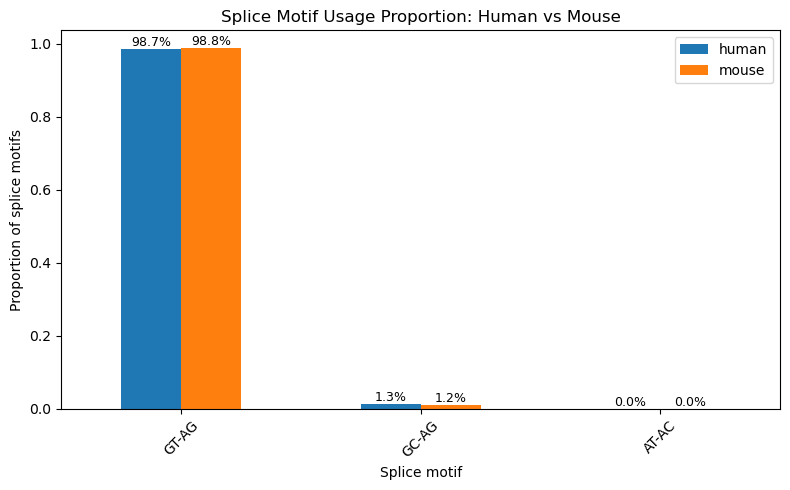

In [3]:
from collections import Counter
import pandas as pd

# Count motif occurrences
human_motifs = Counter(human_atse["splice_motif"])
mouse_motifs = Counter(mouse_atse["splice_motif"])

# Combine into a dataframe
motif_df = pd.DataFrame([human_motifs, mouse_motifs], index=["human", "mouse"]).fillna(0)

# Add proportions
motif_df_prop = motif_df.div(motif_df.sum(axis=1), axis=0)

# Plot the bar chart again with percentages as text
ax = motif_df_prop.T.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Proportion of splice motifs")
ax.set_xlabel("Splice motif")
ax.set_title("Splice Motif Usage Proportion: Human vs Mouse")
plt.xticks(rotation=45)

# Annotate each bar with the percentage value
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height*100:.1f}%", 
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Donor/Acceptor Read Distributions')

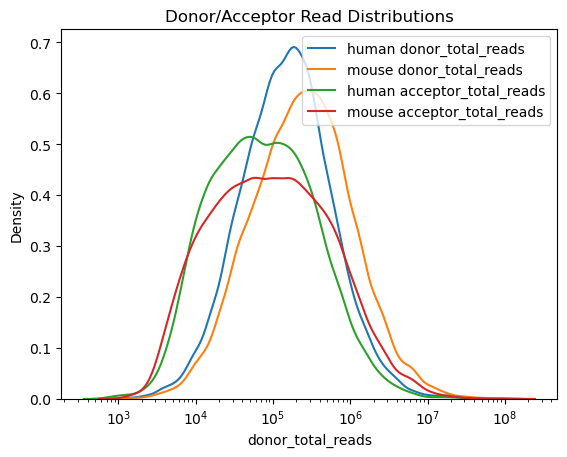

In [4]:
for col in ["donor_total_reads", "acceptor_total_reads"]:
    sns.kdeplot(human_atse[col], label=f"human {col}", log_scale=True)
    sns.kdeplot(mouse_atse[col], label=f"mouse {col}", log_scale=True)
plt.legend()
plt.title("Donor/Acceptor Read Distributions")


In [5]:
o_genes = orthos[["Gene stable ID", "Mouse gene stable ID", "Last common ancestor with Mouse", "Mouse homology type", "Mouse gene name", "Gene name"]].drop_duplicates()
o_genes = o_genes[o_genes["Mouse homology type"].isin(["ortholog_one2one", "ortholog_one2many"])]
o_genes

,Gene stable ID,Mouse gene stable ID,Last common ancestor with Mouse,Mouse homology type,Mouse gene name,Gene name
0,ENSG00000198888,ENSMUSG00000064341,Euarchontoglires,ortholog_one2one,mt-Nd1,MT-ND1
1,ENSG00000198763,ENSMUSG00000064345,Euarchontoglires,ortholog_one2one,mt-Nd2,MT-ND2
2,ENSG00000198804,ENSMUSG00000064351,Euarchontoglires,ortholog_one2one,mt-Co1,MT-CO1
3,ENSG00000198712,ENSMUSG00000064354,Mammalia,ortholog_one2one,mt-Co2,MT-CO2
4,ENSG00000228253,ENSMUSG00000064356,Euarchontoglires,ortholog_one2one,mt-Atp8,MT-ATP8
...,...,...,...,...,...,...
178975,ENSG00000278757,ENSMUSG00000119731,Theria,ortholog_one2many,Gm23096,U6
178976,ENSG00000243749,ENSMUSG00000070737,Euarchontoglires,ortholog_one2one,Tmem35b,TMEM35B
178977,ENSG00000163867,ENSMUSG00000042408,Euarchontoglires,ortholog_one2one,Zmym6,ZMYM6
178986,ENSG00000197056,ENSMUSG00000043872,Euarchontoglires,ortholog_one2one,Zmym1,ZMYM1


In [6]:
mouse_atse["gene_id"] = mouse_atse["gene_id"].str.split(".").str[0]
human_atse["gene_id"] = human_atse["gene_id"].str.split(".").str[0]

mouse_atse["Mouse gene stable ID"] = mouse_atse["gene_id"]
human_atse["Gene stable ID"] = human_atse["gene_id"]
mouse_atse["Mouse gene name"] = mouse_atse["gene_name"]
human_atse["Gene name"] = human_atse["gene_name"]

In [7]:
mouse_atse = mouse_atse.merge(o_genes, on=["Mouse gene stable ID", "Mouse gene name"])
human_atse = human_atse.merge(o_genes, on=["Gene stable ID", "Gene name"])

In [8]:
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Gene stable ID"].isin(human_atse["Gene stable ID"])]

In [9]:
gene=human_atse["Mouse gene stable ID"].sample(n=1).values[0]
human_atse[human_atse["Mouse gene stable ID"] == gene]["event_id"], mouse_atse[mouse_atse["Mouse gene stable ID"] == gene]["event_id"]

(11644    ATSE_4555
 11645    ATSE_4555
 Name: event_id, dtype: object,
 5856    ATSE_2508
 5857    ATSE_2508
 5858    ATSE_2508
 Name: event_id, dtype: object)

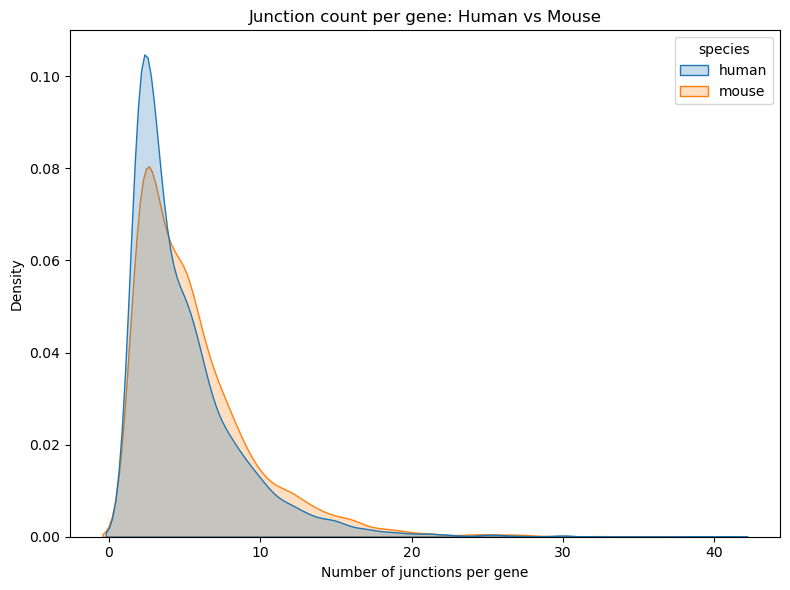

In [10]:
# Count junctions per gene
human_counts = human_atse["gene_id"].value_counts()
mouse_counts = mouse_atse["gene_id"].value_counts()

# Convert value_counts Series into DataFrame
human_df = human_counts.rename("junction_count").reset_index()
human_df["species"] = "human"

mouse_df = mouse_counts.rename("junction_count").reset_index()
mouse_df["species"] = "mouse"

# Combine
combined_df = pd.concat([human_df, mouse_df], ignore_index=True)

# Plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=combined_df, x="junction_count", hue="species", fill=True)
plt.xlabel("Number of junctions per gene")
plt.ylabel("Density")
plt.title("Junction count per gene: Human vs Mouse")
plt.tight_layout()
plt.show()

In [11]:
human_atse["Mouse homology type"].value_counts()

Mouse homology type
ortholog_one2one     15087
ortholog_one2many      409
Name: count, dtype: int64

In [12]:
human_atse = human_atse[human_atse["num_junctions"] <= 3]
mouse_atse = mouse_atse[mouse_atse["num_junctions"] <= 3]

human_atse = human_atse[human_atse["Mouse homology type"] == "ortholog_one2one"]
mouse_atse = mouse_atse[mouse_atse["Mouse homology type"] == "ortholog_one2one"]

gene_strand_info = human_atse.groupby('gene_id')['strand'].nunique().reset_index()
genes_with_multiple_strands = gene_strand_info[gene_strand_info['strand'] > 1]
human_atse = human_atse[~human_atse["gene_id"].isin(genes_with_multiple_strands["gene_id"])]

human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Mouse gene stable ID"].isin(human_atse["Mouse gene stable ID"])]

In [13]:
import pyBigWig
import pandas as pd

def parse_junction(junction_id):
    chrom, start, end, strand = junction_id.split('_')
    return chrom, int(start), int(end), strand


def fetch_scores(bw, chrom, start, end):
    try:
        return bw.stats(chrom, start, end, type='mean')[0]
    except Exception:
        return None

def extract_conservation_scores(junction_event_df, species, side='5p', window=10):
    """
    junction_event_df: DataFrame with at least 'junction_id', 'event_id', 'gene_name' columns
    species: 'human' or 'mouse'
    side: '5p' or '3p' splice site
    window: number of bp upstream/downstream around splice site
    """

    if species == 'human':
        phastcons_bw_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/CROSS_SPECIES_AGING/genome_files/phastCons/hg38.phastCons100way.bw"
        phylop_bw_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/CROSS_SPECIES_AGING/genome_files/phyloP/hg38.phyloP100way.bw"
    elif species == 'mouse':
        phastcons_bw_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/CROSS_SPECIES_AGING/genome_files/phastCons/mm10.60way.phastCons.bw"
        phylop_bw_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/CROSS_SPECIES_AGING/genome_files/phyloP/mm10.60way.phyloP60way.bw"
    else:
        raise ValueError(f"Unknown species {species}")

    phastcons_bw = pyBigWig.open(phastcons_bw_path)
    phylop_bw = pyBigWig.open(phylop_bw_path)

    records = []

    for idx, row in junction_event_df.iterrows():
        junction_id = row['junction_id']
        event_id = row['event_id']
        gene_name = row['Gene name']

        chrom, start, end, strand = parse_junction(junction_id)

        phastcons_score = fetch_scores(phastcons_bw, chrom, start, end)
        phylop_score = fetch_scores(phylop_bw, chrom, start, end)

        records.append({
            'gene_name': gene_name,
            'event_id': event_id,
            'junction_id': junction_id,
            'chrom': chrom,
            'start': start,
            'end': end,
            'strand': strand,
            'phastCons_mean': phastcons_score,
            'phyloP_mean': phylop_score
        })

    phastcons_bw.close()
    phylop_bw.close()

    return pd.DataFrame(records)

In [14]:
gene_name = human_atse["Gene name"].sample(n=1)
print(gene_name.values)

# Include gene_name in the subset!
human_junction_ids = human_atse[human_atse["Gene name"] == gene_name.values[0]][["junction_id", "event_id", "Gene name"]]
mouse_junction_ids = mouse_atse[mouse_atse["Gene name"] == gene_name.values[0]][["junction_id", "event_id", "Gene name"]]

# Human junctions
df_human_scores = extract_conservation_scores(
    human_junction_ids,
    species='human',
    window=10
)

# Mouse junctions
df_mouse_scores = extract_conservation_scores(
    mouse_junction_ids,
    species='mouse',
    window=10
)

['HNRNPH3']


In [25]:
df_mouse_scores

,gene_name,event_id,junction_id,chrom,start,end,strand,phastCons_mean,phyloP_mean
0,HNRNPH3,ATSE_3157,chr10_63018898_63019392_-,chr10,63018898,63019392,-,0.671778,1.920343
1,HNRNPH3,ATSE_3157,chr10_63018225_63019392_-,chr10,63018225,63019392,-,0.836413,2.647465
2,HNRNPH3,ATSE_3157,chr10_63018225_63018759_-,chr10,63018225,63018759,-,0.875123,2.184350
3,HNRNPH3,ATSE_3158,chr10_63017610_63018058_-,chr10,63017610,63018058,-,0.497853,1.421014
4,HNRNPH3,ATSE_3158,chr10_63017610_63018040_-,chr10,63017610,63018040,-,0.476915,1.344757
5,HNRNPH3,ATSE_3158,chr10_63017610_63018085_-,chr10,63017610,63018085,-,0.526284,1.524563


In [26]:
df_human_scores

,gene_name,event_id,junction_id,chrom,start,end,strand,phastCons_mean,phyloP_mean
0,HNRNPH3,ATSE_5506,chr10_68337996_68338502_+,chr10,68337996,68338502,+,0.876312,2.853616
1,HNRNPH3,ATSE_5506,chr10_68337333_68337857_+,chr10,68337333,68337857,+,0.561121,2.175133
2,HNRNPH3,ATSE_5506,chr10_68337333_68338502_+,chr10,68337333,68338502,+,0.725103,3.075317
3,HNRNPH3,ATSE_5507,chr10_68338687_68339139_+,chr10,68338687,68339139,+,0.365182,1.278939
4,HNRNPH3,ATSE_5507,chr10_68338642_68339139_+,chr10,68338642,68339139,+,0.422655,1.599594
5,HNRNPH3,ATSE_5508,chr10_68332216_68337198_+,chr10,68332216,68337198,+,0.194120,0.435796
6,HNRNPH3,ATSE_5508,chr10_68332235_68337198_+,chr10,68332235,68337198,+,0.193762,0.436156


In [15]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment
from pyfaidx import Fasta
from Bio.Seq import Seq

# Load genome
human_genome = Fasta("/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/GRCh38.primary_assembly.genome.fa")
mouse_genome = Fasta("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/fasta/genome.fa")

def get_full_junction_sequence(chrom, start, end, strand, genome_fasta, window=0):
    """
    Extract full junction sequence from start to end with optional ±window expansion.
    """
    seq_start = max(start - window, 0)
    seq_end = end + window

    seq = genome_fasta[chrom][seq_start:seq_end].seq

    if strand == '-':
        seq = str(Seq(seq).reverse_complement())

    return seq

def sequence_identity(seq1, seq2):
    """Compute percent identity between two sequences."""
    alignments = pairwise2.align.globalxx(seq1, seq2, one_alignment_only=True)
    aln1, aln2, score, start, end = alignments[0]
    matches = sum(c1 == c2 for c1, c2 in zip(aln1, aln2))
    return matches / max(len(seq1), len(seq2))

/gpfs/commons/home/kisaev/miniconda3/envs/LeafletSC/lib/python3.10/site-packages/Bio/pairwise2.py:278: BiopythonDeprecationWarning: Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still need the Bio.pairwise2 module.
  warnings.warn(


In [16]:
# For human junctions
human_junctions = []
for idx, row in df_human_scores.iterrows():
    seq = get_full_junction_sequence(row['chrom'], row['start'], row['end'], row['strand'], human_genome, window=10)
    human_junctions.append({
        'seq': seq,
        'junction_id': row['junction_id'],
        'event_id': row['event_id'],
        'gene_name': row['gene_name']  # Optional but useful
    })

# For mouse junctions
mouse_junctions = []
for idx, row in df_mouse_scores.iterrows():
    seq = get_full_junction_sequence(row['chrom'], row['start'], row['end'], row['strand'], mouse_genome, window=10)
    mouse_junctions.append({
        'seq': seq,
        'junction_id': row['junction_id'],
        'event_id': row['event_id'],
        'gene_name': row['gene_name']  # Optional but useful
    })


In [17]:
import numpy as np
from tqdm import tqdm

def calculate_alignment_matrix(human_junctions, mouse_junctions, verbose=True):
    """
    Returns:
    - score_matrix: (num_human_junctions x num_mouse_junctions)
    - human_junction_ids: list of human junction ids
    - mouse_junction_ids: list of mouse junction ids
    - average_best_score: average of best matches
    """

    score_matrix = np.zeros((len(human_junctions), len(mouse_junctions)))

    human_junction_ids = [h['junction_id'] for h in human_junctions]
    mouse_junction_ids = [m['junction_id'] for m in mouse_junctions]

    human_atses = [h['event_id'] for h in human_junctions]
    mouse_atses = [h['event_id'] for h in mouse_junctions]

    for i, h in enumerate(tqdm(human_junctions, desc="Aligning human junctions", disable=not verbose)):
        for j, m in enumerate(mouse_junctions):
            score = sequence_identity(h['seq'], m['seq'])
            score_matrix[i, j] = score

    # Calculate average best score
    total_score = 0
    count = 0
    for i in range(score_matrix.shape[0]):
        best_score = score_matrix[i, :].max()
        total_score += best_score
        count += 1

    return score_matrix, human_junction_ids, mouse_junction_ids, human_atses, mouse_atses

In [18]:
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap

def calculate_alignment_matrix(human_junctions, mouse_junctions, verbose=True):
    """
    Returns:
    - score_matrix: (num_human_junctions x num_mouse_junctions)
    - human_junction_ids: list of human junction ids
    - mouse_junction_ids: list of mouse junction ids 
    - human_atses: list of human ATSE ids
    - mouse_atses: list of mouse ATSE ids
    - average_best_score: average of best matches
    """
    
    score_matrix = np.zeros((len(human_junctions), len(mouse_junctions)))
    
    human_junction_ids = [h['junction_id'] for h in human_junctions]
    mouse_junction_ids = [m['junction_id'] for m in mouse_junctions]
    
    human_atses = [h['event_id'] for h in human_junctions]
    mouse_atses = [m['event_id'] for m in mouse_junctions]
    
    for i, h in enumerate(tqdm(human_junctions, desc="Aligning human junctions", disable=not verbose)):
        for j, m in enumerate(mouse_junctions):
            score = sequence_identity(h['seq'], m['seq'])
            score_matrix[i, j] = score
    
    # Calculate average best score
    total_score = 0
    count = 0
    for i in range(score_matrix.shape[0]):
        best_score = score_matrix[i, :].max()
        total_score += best_score
        count += 1
    
    avg_score = total_score / count if count > 0 else 0
    
    return score_matrix, human_junction_ids, mouse_junction_ids, human_atses, mouse_atses, avg_score

# Run
score_matrix, human_junction_ids, mouse_junction_ids, human_atses, mouse_atses, avg_score = calculate_alignment_matrix(human_junctions, mouse_junctions)

# Build a labeled DataFrame
score_df = pd.DataFrame(score_matrix, index=human_junction_ids, columns=mouse_junction_ids)

# Create maps for ATSE to color
def create_atse_color_mapping(atse_list):
    unique_atses = list(set(atse_list))
    atse_to_idx = {atse: i for i, atse in enumerate(unique_atses)}
    return atse_to_idx

# Get unique ATSE groups and assign colors
human_atse_to_idx = create_atse_color_mapping(human_atses)
mouse_atse_to_idx = create_atse_color_mapping(mouse_atses)

# Create row colors for human junctions
row_colors = [human_atse_to_idx[atse] for atse in human_atses]
# Create column colors for mouse junctions
col_colors = [mouse_atse_to_idx[atse] for atse in mouse_atses]

# Create color palettes (using different colormaps for rows and columns for better distinction)
num_human_atses = len(set(human_atses))
num_mouse_atses = len(set(mouse_atses))
human_cmap = plt.cm.get_cmap('tab10', num_human_atses)
mouse_cmap = plt.cm.get_cmap('Set1', num_mouse_atses)

# Convert to color lists
row_colors_list = [human_cmap(i) for i in row_colors]
col_colors_list = [mouse_cmap(i) for i in col_colors]

Aligning human junctions: 100%|██████████| 7/7 [00:55<00:00,  7.95s/it]
/scratch/ipykernel_4182153/3171725957.py:69: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  human_cmap = plt.cm.get_cmap('tab10', num_human_atses)
/scratch/ipykernel_4182153/3171725957.py:70: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  mouse_cmap = plt.cm.get_cmap('Set1', num_mouse_atses)


In [28]:
human_junctions

[{'seq': 'TAGGGCACAGGTGGGGATGGAGAGTTTGGGATGGTGTTAAATTTTTATTTTTGGGGGTTGTGGGTCACTATTGCTTAAATGGGGGGGTAGCCATAACATTTTTCTGGGGTAGTTTAAAAGAATTGATAATTATCTAAATTTAACTTGGAAACTACAGATTTGGGTGGGGAATTAATGCTAATAGTTAAATTAAAATTAGATTGTTTCCATTTCTCTGTAGGATGTTGTTGATAAATGCTTTTGTATAATCACCTATTTCCTTTAAAACACCTATTATGTACTAAAAGAGACAAAGTAAAAATATACTTTATGAATTGTTTTCCGTGACTAATTTCTTTGTAAAACTTAAATATTTAATTAAGTTTGTAGGTTTAAACTGTTAACTTACGGTGTATTTAGGCAATTTAAATTGGGTTATGTATCTAGATATAGAAAAACTTACTGCATTTTGCCCAGTATCTAATTTACACTAATACATTTATGCTGAAACCTGTACCTTAAAACATTTTTAAATAGGTATATTGAG',
  'junction_id': 'chr10_68337996_68338502_+',
  'event_id': 'ATSE_5506',
  'gene_name': 'HNRNPH3'},
 {'seq': 'TTCTTTCAAGGTACCTCTAGTATTAGTCAAAGTTTAGTAGTATTGTAATTTTATATTTGTATTGTTTTACTGTTTTTAATTTGTAAAACCCATTTGATTTTGGAACTTTTAAGTTTAACTATGATAGTCTTGGTTAATGTATTAAAATAATATGCTCCAGTTAATATTCAATACAGAATGTGTAGAATATGTAAAACCTAGTTAATGTGCAGTAACATATTTGAGAATTGTGATGAAATGAACCGTGAATTAGTATATGGAGCATATATTTGATTTTGTAGCCTTTTTTCATGTAATATAGGTGGGCTTTTAGAGTGTGTAATTACACAGTGTTTTTACACTGGTCGCAAA

<Figure size 1400x1200 with 0 Axes>

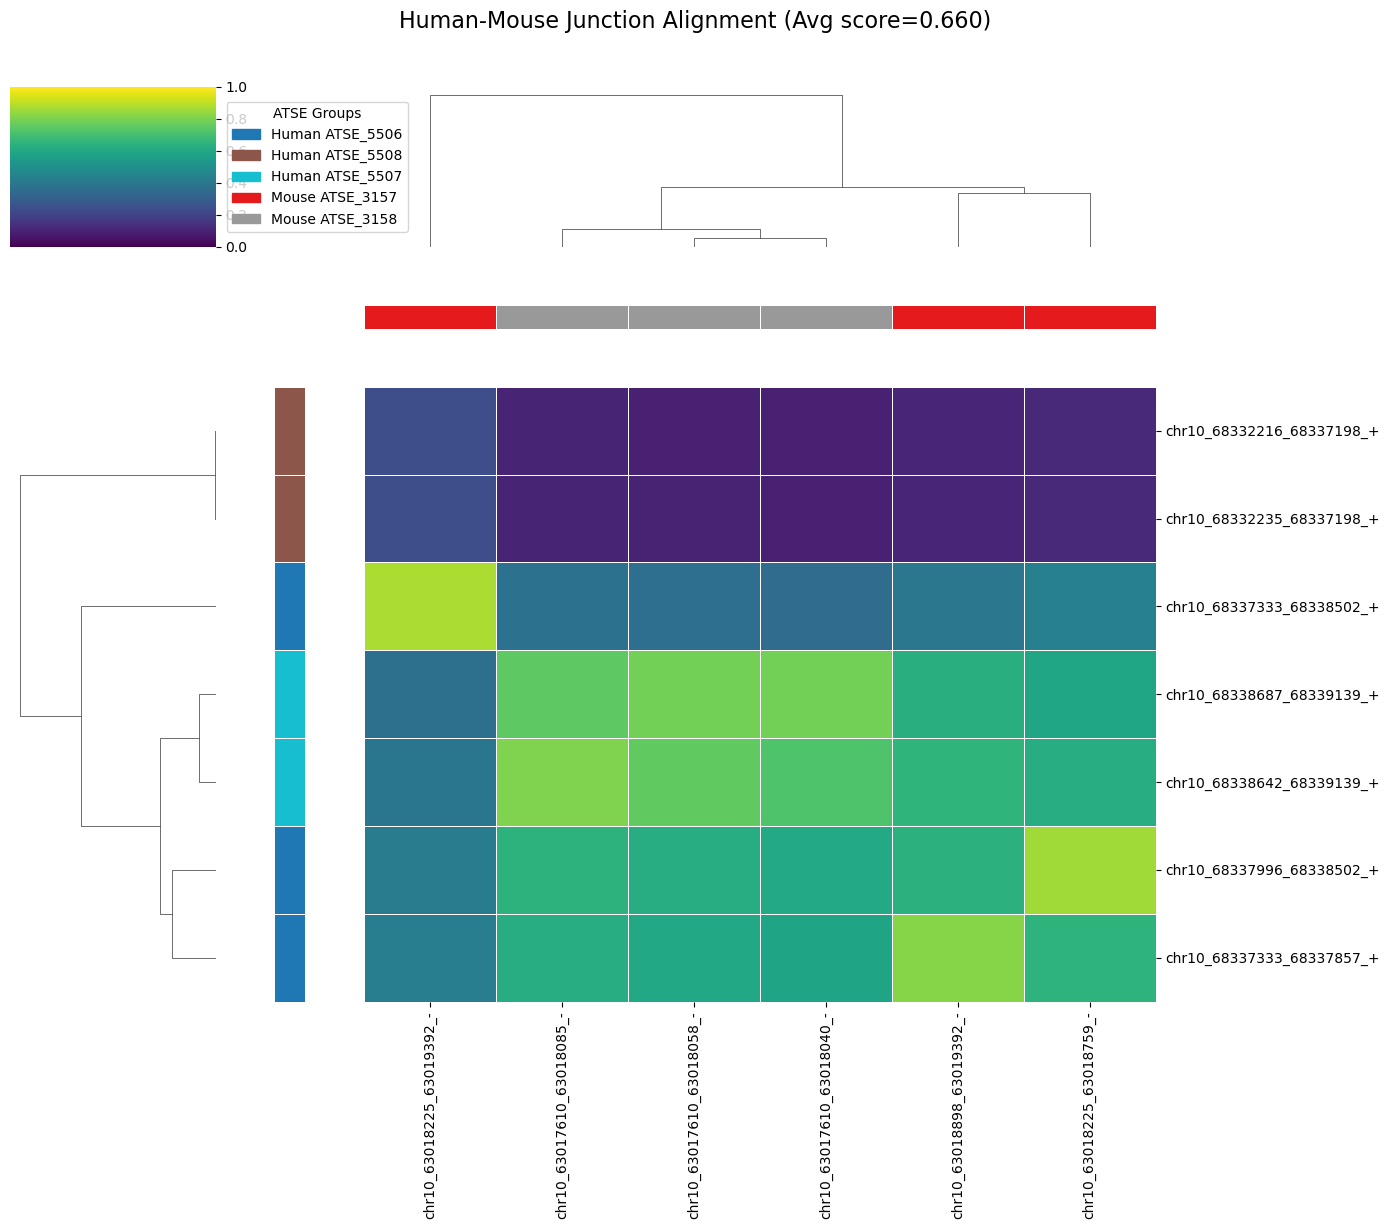

In [19]:
# Plot with colored rows and columns
plt.figure(figsize=(14, 12))
g = sns.clustermap(
    score_df, 
    cmap='viridis', 
    vmin=0, 
    vmax=1, 
    linewidths=0.5, 
    figsize=(14, 12),
    row_colors=row_colors_list,
    col_colors=col_colors_list,
)

# Add legends for ATSEs
row_handles = []
for atse, idx in human_atse_to_idx.items():
    row_handles.append(mpatches.Patch(color=human_cmap(idx), label=f"Human {atse}"))

col_handles = []
for atse, idx in mouse_atse_to_idx.items():
    col_handles.append(mpatches.Patch(color=mouse_cmap(idx), label=f"Mouse {atse}"))

all_handles = row_handles + col_handles
plt.legend(handles=all_handles, title="ATSE Groups", 
           bbox_to_anchor=(1.02, 0.5), loc='center left')

# Add title
plt.suptitle(f"Human-Mouse Junction Alignment (Avg score={avg_score:.3f})", 
             y=1.02, fontsize=16)

plt.tight_layout()
plt.show()

### To do:
- 100 bases outside of the junction as the sequence rep / seperatley align each end and conserved if both align  
- 

In [22]:
def annotate_gene_junctions(gene_id, db):
    """
    Annotate all junctions (introns) in all transcripts of a given gene.
    
    Args:
        gene_id (str): The ID of the gene to analyze
        db (gffutils.FeatureDB): Database object created from GTF file
        fasta_file (str, optional): Path to genome FASTA file for sequence extraction
    
    Returns:
        dict: Dictionary of junctions with their annotations
    """
    # Dictionary to store junction data
    junctions = {}
    
    try:
        # Get the gene
        gene = db[gene_id]
        print(f"Analyzing gene: {gene_id}")
        
        # Get all transcripts for this gene
        transcripts = list(db.children(gene, featuretype="transcript"))
        print(f"Found {len(transcripts)} transcripts")
        
        # Process each transcript
        for transcript in transcripts:
            transcript_id = transcript.id
            strand = transcript.strand
            
            # Get exons for this transcript
            exons = list(db.children(transcript, featuretype="exon", order_by="start"))
            
            # Skip transcripts with less than 2 exons (no introns)
            if len(exons) < 2:
                continue
                
            # Extract introns from adjacent exons
            for i in range(len(exons) - 1):
                if strand == '+':
                    junction_start = exons[i].end
                    junction_end = exons[i+1].start
                else:  # strand == '-'
                    junction_start = exons[i+1].end
                    junction_end = exons[i].start
                
                # Create a unique junction ID
                junction_id = f"{transcript.chrom}:{min(junction_start, junction_end)}-{max(junction_start, junction_end)}:{strand}"
                
                # Update or create junction data
                if junction_id not in junctions:
                    junction_data = {
                        "chrom": transcript.chrom,
                        "start": min(junction_start, junction_end),
                        "end": max(junction_start, junction_end),
                        "strand": strand,
                        "gene_ids": [gene_id],
                        "gene_names": [gene.attributes.get('gene_name', [''])[0]],
                        "gene_types": [gene.attributes.get('gene_type', 
                                      gene.attributes.get('gene_biotype', ['']))[0]],
                        "transcripts": [transcript_id],
                        "total_score": 0,  # Default score for annotation
                        "annotation_status": "annotated"
                    }
                    
                    junctions[junction_id] = junction_data
                else:
                    # Update existing junction with this transcript
                    junctions[junction_id]["transcripts"].append(transcript_id)
            
        print(f"Identified {len(junctions)} unique junctions in gene {gene_id}")
        
        # Convert to DataFrame for easier manipulation if needed
        junctions_df = pd.DataFrame.from_dict(junctions, orient='index')
        junctions_df.reset_index(inplace=True)
        junctions_df.rename(columns={'index': 'junction_id'}, inplace=True)
        
        return {
            "junctions_dict": junctions,
            "junctions_df": junctions_df
        }
        
    except Exception as e:
        print(f"Error processing gene {gene_id}: {str(e)}")
        return None

Plot saved to test.pdf!


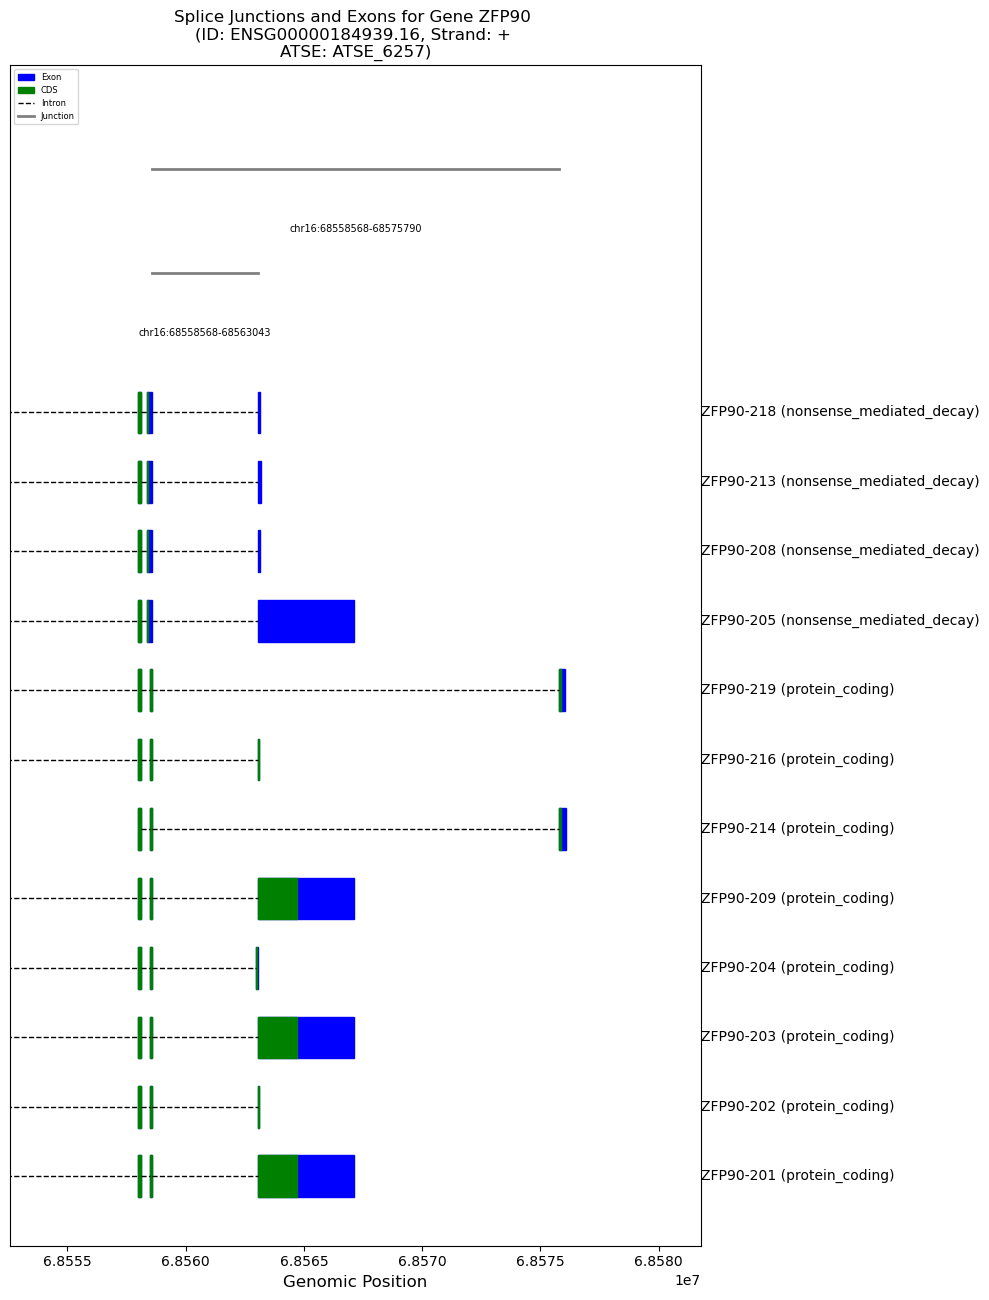

In [21]:
mouse_result = process_and_visualize_atse_event("ATSE_6257", human_atse, db_human, filename="test.pdf")

In [23]:
# Initialize your genome database
fasta_file ="/gpfs/commons/datasets/controlled/BRAIN_NeMO/human-reference/gencode/GRCh38.primary_assembly.genome.fa"

# Annotate junctions for a specific gene
gene_id = "ENSG00000223972.6"  # For example, BRCA2
result = annotate_gene_junctions(gene_id, db_human)

# Access the results
junctions_dict = result["junctions_dict"]
junctions_df = result["junctions_df"]

# Display the first few junctions
print(junctions_df.head())

Analyzing gene: ENSG00000223972.6
Found 1 transcripts
Identified 5 unique junctions in gene ENSG00000223972.6
          junction_id chrom  start    end strand             gene_ids  \
0  chr1:12057-12179:+  chr1  12057  12179      +  [ENSG00000223972.6]   
1  chr1:12227-12613:+  chr1  12227  12613      +  [ENSG00000223972.6]   
2  chr1:12697-12975:+  chr1  12697  12975      +  [ENSG00000223972.6]   
3  chr1:13052-13221:+  chr1  13052  13221      +  [ENSG00000223972.6]   
4  chr1:13374-13453:+  chr1  13374  13453      +  [ENSG00000223972.6]   

  gene_names                            gene_types          transcripts  \
0  [DDX11L1]  [transcribed_unprocessed_pseudogene]  [ENST00000450305.2]   
1  [DDX11L1]  [transcribed_unprocessed_pseudogene]  [ENST00000450305.2]   
2  [DDX11L1]  [transcribed_unprocessed_pseudogene]  [ENST00000450305.2]   
3  [DDX11L1]  [transcribed_unprocessed_pseudogene]  [ENST00000450305.2]   
4  [DDX11L1]  [transcribed_unprocessed_pseudogene]  [ENST00000450305.2]   

